In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

<h3>1. Load the Data</h3>

In [2]:
#Load the dataset
df = pd.read_csv("heart.csv")

In [3]:
print(df.head())
print(df.shape)
print(df.info())
print(df.isna().sum())
print(df.describe())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
(303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    i

Using df.head(), the first few rows were reviewed to understand the basic structure of the dataset and the type of values in each column. 
</br>The size and column data types were identified with df.shape and df.info(), showing 303 rows, 14 columns, and all numeric variables. 
</br>Missing values were checked with df.isna().sum(), and none were found.
</br>Finally, df.describe() summarized the numeric features by showing their ranges, averages, and overall variability.

<h3>2. Clean the Data</h3>

Missing values not found, so no dropping/imputation needed.

In [4]:
#Binary Columns (0/1) to category
binary_cols = ["sex","fbs","exang","target"]
for col in binary_cols:
    df[col] =df[col].astype("category")

#Categorial to category
categorial_cols = ["cp","restecg","slope","thal","ca"]
for col in categorial_cols:
    df[col] =df[col].astype("category")

#Create Clean data frame
df_clean = df.copy()

#Rename columns for clarity 
df_clean = df_clean.rename(columns={
    "trestbps":"resting_bp",
    "thalach":"max_hr",
    "oldpeak":"st_depression",
    "chol":"cholesterol"
})

print(df_clean.head(10))

   age sex cp  resting_bp  cholesterol fbs restecg  max_hr exang  \
0   63   1  3         145          233   1       0     150     0   
1   37   1  2         130          250   0       1     187     0   
2   41   0  1         130          204   0       0     172     0   
3   56   1  1         120          236   0       1     178     0   
4   57   0  0         120          354   0       1     163     1   
5   57   1  0         140          192   0       1     148     0   
6   56   0  1         140          294   0       0     153     0   
7   44   1  1         120          263   0       1     173     0   
8   52   1  2         172          199   1       1     162     0   
9   57   1  2         150          168   0       1     174     0   

   st_depression slope ca thal target  
0            2.3     0  0    1      1  
1            3.5     0  0    2      1  
2            1.4     2  0    2      1  
3            0.8     2  0    2      1  
4            0.6     2  0    2      1  
5          

<h3>3. Simple Random Sampling</h3>

In [5]:
# andom samples
sample_50 = df_clean.sample(50, random_state=1)
sample_100 = df_clean.sample(100, random_state=1)
sample_200 = df_clean.sample(200, random_state=1)

# Select variable
numeric_var = "age"

# To calculate stats
def calc_stats(data, label):
    return {
        "Dataset": label,
        "Mean (age)": round(data[numeric_var].mean(), 2),
        "Std Dev (age)": round(data[numeric_var].std(), 2)
    }

# Results table
results = pd.DataFrame([
    calc_stats(df_clean, "Full Data"),
    calc_stats(sample_50, "Sample 50"),
    calc_stats(sample_100, "Sample 100"),
    calc_stats(sample_200, "Sample 200")
])

results

,Dataset,Mean (age),Std Dev (age)
0,Full Data,54.37,9.08
1,Sample 50,53.88,9.15
2,Sample 100,55.28,8.69
3,Sample 200,55.09,8.84


As the sample size increases, the mean and standard deviation of age become closer to the values from the full dataset. The smallest sample (50) shows more variation, especially in the standard deviation. Larger samples (100 and 200) produce more stable and consistent estimates. This happens because larger samples better represent the population. Therefore, bigger samples generally give more reliable and less variable results. 

<h3>4. Stratified Sampling</h3>

In [6]:
cat_var = "sex"
num_var = "age"
sample_size = 200

df_clean[cat_var].value_counts(normalize=True)

# Create a stratified sample of size 200

group_counts = df_clean[cat_var].value_counts(normalize=True)
group_sample_sizes = (group_counts * sample_size).round().astype(int)

# Collect samples
samples = []
for group, n in group_sample_sizes.items():
    group_data = df_clean[df_clean[cat_var] == group]
    samples.append(group_data.sample(n, random_state=1))

# Combine all groups into one stratified sample
strat_sample = pd.concat(samples)

# Compare counts and mean age by group
rows = []
for group in strat_sample[cat_var].unique():
    group_data = strat_sample[strat_sample[cat_var] == group]

    rows.append({
        cat_var: group,
        "count": len(group_data),
        "mean": group_data[num_var].mean()
    })
comparison = pd.DataFrame(rows)

print(comparison)

   sex  count       mean
0    1    137  53.481752
1    0     63  55.619048


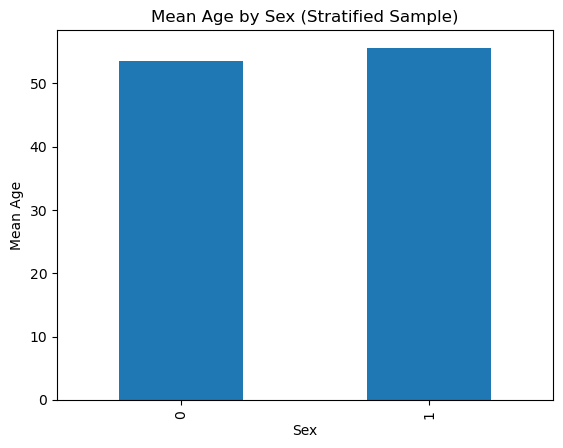

In [7]:
# Bar plot comparing mean age by group
plt.figure()
comparison["mean"].plot(kind="bar")
plt.xlabel("Sex")
plt.ylabel("Mean Age")
plt.title("Mean Age by Sex (Stratified Sample)")
plt.show()

Stratified sampling keeps the same proportion of each group as in the original dataset, so important categories are not underrepresented. In this example, both sex groups appear in the sample in similar proportions to the full data. This makes the group-level mean age more reliable and easier to compare. Random sampling may accidentally include too many or too few observations from a smaller group. Therefore, stratified sampling is often better when subgroup representation is important for analysis.

<h3>5. Confidence Interval + Hypothesis Test</h3>

<h5>Is average chol different between males and females?</h5>

In [8]:
# A random sample of 200
sample_200 = df_clean.sample(200, random_state=1)

# Split cholesterol by sex
chol_male = sample_200[sample_200["sex"] == 1]["cholesterol"]
chol_female = sample_200[sample_200["sex"] == 0]["cholesterol"]

# Difference in means
mean_diff = chol_male.mean() - chol_female.mean()


In [9]:
# 95% Confidence Interval
se_diff = np.sqrt(
    chol_male.var(ddof=1) / len(chol_male) +
    chol_female.var(ddof=1) / len(chol_female)
)
print(se_diff)

9.760621134953677


In [10]:
# Hypothesis test (Welch’s t-test)
ci_low = mean_diff - 1.96 * se_diff
ci_high = mean_diff + 1.96 * se_diff
t_stat, p_value = stats.ttest_ind(chol_male, chol_female, equal_var=False)

mean_diff, (ci_low, ci_high), p_value

(-29.53574325107175,
 (-48.66656067558095, -10.404925826562543),
 0.003286238992041971)

The 95% confidence interval shows that the average cholesterol level for males is about 10 to 49 mg/dL lower than for females. Because the interval does not include zero, it suggests that the difference is real and not due to chance. <br/>
The hypothesis test gives a p-value of 0.003, which is smaller than 0.05, so the null hypothesis is rejected. This means the average cholesterol levels are different between males and females. In simple terms, men and women in this dataset do not have the same average cholesterol, and this difference is statistically meaningful.

<h3>6. Simulation</h3>

In [11]:
# Simulation variables
numeric_var = "age"
sample_size = 100
n_simulations = 200

# Full dataset mean
full_mean = df_clean[numeric_var].mean()

In [12]:
# Repeat sampling
mean_list = []
for i in range(n_simulations):
    sample = df_clean.sample(sample_size)
    mean_list.append(sample[numeric_var].mean())


print(full_mean)

54.366336633663366


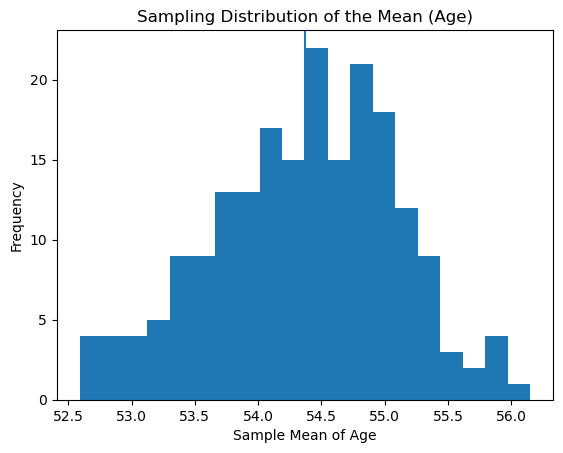

In [13]:
plt.figure()
plt.hist(mean_list, bins=20)
plt.axvline(full_mean)
plt.xlabel("Sample Mean of Age")
plt.ylabel("Frequency")
plt.title("Sampling Distribution of the Mean (Age)")
plt.show()

The sample means looks approximately normal based on the plot, even though the original age data may not be perfectly normal. </br>
This happens because repeated sampling causes the means to cluster around the true average. The full-data mean is close to the center of the histogram, which shows that the sampling process is unbiased. Sampling variability means that each random sample gives a slightly different mean due to random chance. Even with the same sample size, results will vary, but most values stay close to the true population mean.

<h3>7. Ethical Reflection</h3>

Poor sampling can lead to unfair or incorrect results in healthcare by over-representing some patient groups and under-representing others. For example, if a dataset includes mostly one gender or age group, the results may not apply to the wider patient population. This can cause biased conclusions and may affect clinical decisions, treatment guidelines, or resource allocation. Small or unbalanced samples can also exaggerate differences that are not truly meaningful. To reduce these risks, careful sampling methods such as stratified sampling should be used to ensure key groups are properly represented. In addition, results should always be reported with uncertainty measures, such as confidence intervals, to avoid overconfidence. Transparent documentation of data limitations is also important for ethical healthcare analysis.

<h3>8. Final Summary</h3>

In this Sampling analysis, I learned how basic data inspection, cleaning, sampling, and statistical methods work together in data science. I explored random and stratified sampling, calculated summary statistics, and used simulations to understand sampling variability. Confidence intervals and hypothesis testing helped me see how uncertainty and statistical evidence are used to answer real-world questions. I also learned that larger and better-designed samples produce more stable and reliable results.The biggest insight from this homework was how much sampling choice affects conclusions. Even when using the same dataset, different samples can produce slightly different results, and poor sampling can lead to biased or misleading outcomes. Seeing the sampling distribution through simulation made the idea of variability much clearer than theory alone. <br/>
Next, I would like to study more advanced methods such as bootstrap confidence intervals and regression analysis to understand relationships between multiple variables. I am also interested in learning more about bias detection and fairness in healthcare data, especially when working with sensitive patient information.